In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

In [2]:
train_df = pd.read_csv("../data/raw/train_FD001.txt", sep = r'\s+', header = None)

In [3]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
train_df.shape

(20631, 26)

In [5]:
train_df[0].nunique()

100

In [6]:
train_df.groupby(0)[1].max()

0
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: 1, Length: 100, dtype: int64

In [7]:
column_names = [
    "unit_id",
    "cycle",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",
] + [f"sensor_{i}" for i in range(1, 22)]

len(column_names)

26

In [8]:
train_df.columns = column_names

In [9]:
train_df.head()

,unit_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_id                20631 non-null  int64  
 1   cycle                  20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  sensor_11    

In [11]:
train_df.describe()

,unit_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [12]:
train_df.nunique()

unit_id                   100
cycle                     362
operational_setting_1     158
operational_setting_2      13
operational_setting_3       1
sensor_1                    1
sensor_2                  310
sensor_3                 3012
sensor_4                 4051
sensor_5                    1
sensor_6                    2
sensor_7                  513
sensor_8                   53
sensor_9                 6403
sensor_10                   1
sensor_11                 159
sensor_12                 427
sensor_13                  56
sensor_14                6078
sensor_15                1918
sensor_16                   1
sensor_17                  13
sensor_18                   1
sensor_19                   1
sensor_20                 120
sensor_21                4745
dtype: int64

In [13]:
train_df.nunique() == 1

unit_id                  False
cycle                    False
operational_setting_1    False
operational_setting_2    False
operational_setting_3     True
sensor_1                  True
sensor_2                 False
sensor_3                 False
sensor_4                 False
sensor_5                  True
sensor_6                 False
sensor_7                 False
sensor_8                 False
sensor_9                 False
sensor_10                 True
sensor_11                False
sensor_12                False
sensor_13                False
sensor_14                False
sensor_15                False
sensor_16                 True
sensor_17                False
sensor_18                 True
sensor_19                 True
sensor_20                False
sensor_21                False
dtype: bool

In [14]:
constant_mask = train_df.nunique() == 1

constant_columns = constant_mask[constant_mask].index.tolist()

constant_columns

['operational_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

In [15]:
train_df = train_df.drop(columns = constant_columns)

In [16]:
train_df.columns

Index(['unit_id', 'cycle', 'operational_setting_1', 'operational_setting_2',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8',
       'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14',
       'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'],
      dtype='str')

In [17]:
train_df.shape

(20631, 19)

In [18]:
engine_1_mask = train_df["unit_id"] == 1

engine_1_rows = train_df[engine_1_mask]

engine_1_rows

,unit_id,cycle,operational_setting_1,operational_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,643.75,1602.38,1422.78,21.61,551.94,2388.31,9037.91,48.00,519.79,2388.23,8117.69,8.5207,396,38.51,22.9588
188,1,189,-0.0006,0.0002,644.18,1596.17,1428.01,21.61,550.70,2388.27,9044.55,48.08,519.58,2388.33,8117.51,8.5183,395,38.48,23.1127
189,1,190,-0.0027,0.0001,643.64,1599.22,1425.95,21.61,551.29,2388.29,9040.58,48.33,520.04,2388.35,8112.58,8.5223,398,38.49,23.0675
190,1,191,-0.0000,-0.0004,643.34,1602.36,1425.77,21.61,550.92,2388.28,9042.76,48.15,519.57,2388.30,8114.61,8.5174,394,38.45,23.1295


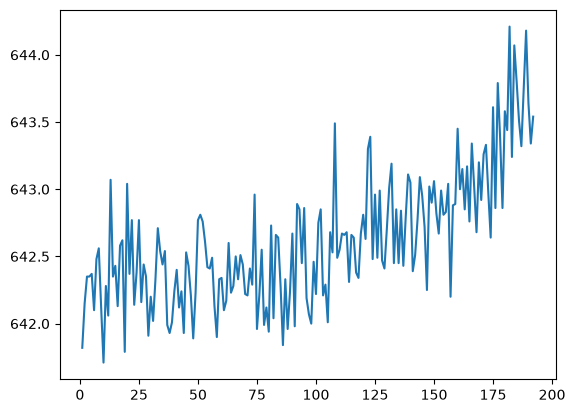

In [19]:
plt.plot(engine_1_rows["cycle"], engine_1_rows["sensor_2"])

In [20]:
engine_2_mask = train_df["unit_id"] == 2

engine_2_rows = train_df[engine_2_mask]

engine_2_rows

,unit_id,cycle,operational_setting_1,operational_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
192,2,1,-0.0018,0.0006,641.89,1583.84,1391.28,21.60,554.53,2388.01,9054.72,46.93,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585
193,2,2,0.0043,-0.0003,641.82,1587.05,1393.13,21.61,554.77,2387.98,9051.31,47.24,522.70,2387.98,8131.09,8.4167,392,39.06,23.4085
194,2,3,0.0018,0.0003,641.55,1588.32,1398.96,21.60,555.14,2388.04,9054.24,47.22,522.58,2387.99,8140.58,8.3802,391,39.11,23.4250
195,2,4,0.0035,-0.0004,641.68,1584.15,1396.08,21.61,554.25,2387.98,9058.01,47.10,522.49,2387.93,8140.44,8.4018,391,39.13,23.5027
196,2,5,0.0005,0.0004,641.73,1579.03,1402.52,21.60,555.12,2388.03,9058.15,47.25,522.27,2387.94,8136.67,8.3867,390,39.18,23.4234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,2,283,0.0046,0.0002,643.78,1602.03,1429.67,21.61,551.46,2388.16,9084.13,48.21,520.07,2388.20,8174.85,8.5199,398,38.42,23.0358
475,2,284,-0.0006,0.0001,643.91,1601.35,1430.04,21.61,551.96,2388.22,9089.87,48.18,519.95,2388.21,8166.83,8.5291,395,38.23,23.1196
476,2,285,-0.0007,0.0004,643.67,1596.84,1431.17,21.61,550.85,2388.20,9098.67,48.27,519.91,2388.22,8164.83,8.5242,396,38.39,23.1155
477,2,286,-0.0010,-0.0003,643.44,1603.63,1429.57,21.61,551.61,2388.18,9102.01,48.14,519.51,2388.22,8169.97,8.4932,395,38.33,23.0169


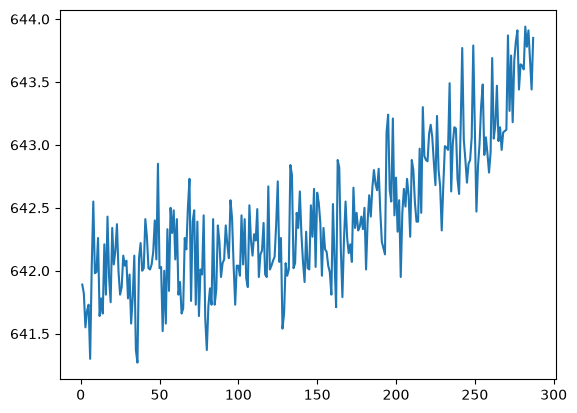

In [21]:
plt.plot(engine_2_rows["cycle"], engine_2_rows["sensor_2"])

In [22]:
train_df["RUL"] = train_df.groupby("unit_id")["cycle"].transform("max") - train_df["cycle"]

In [23]:
engine_1_mask = train_df["unit_id"] == 1

engine_1_rows = train_df[engine_1_mask][["unit_id", "cycle", "RUL"]]

engine_1_rows


,unit_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
...,...,...,...
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1


In [24]:
sensor_columns = []

for column in train_df.columns:
    if column.startswith("sensor_"):
        sensor_columns.append(column)
sensor_columns

['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

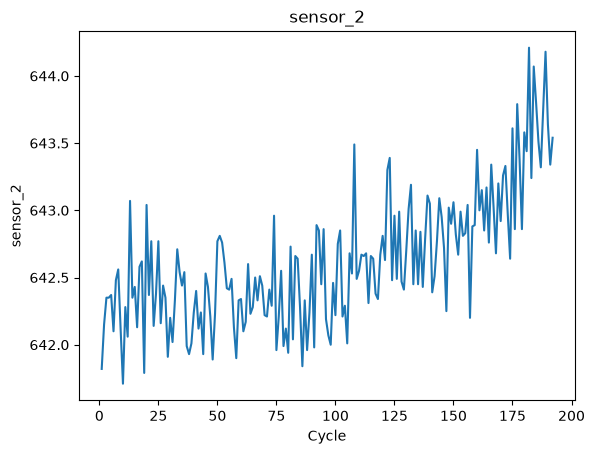

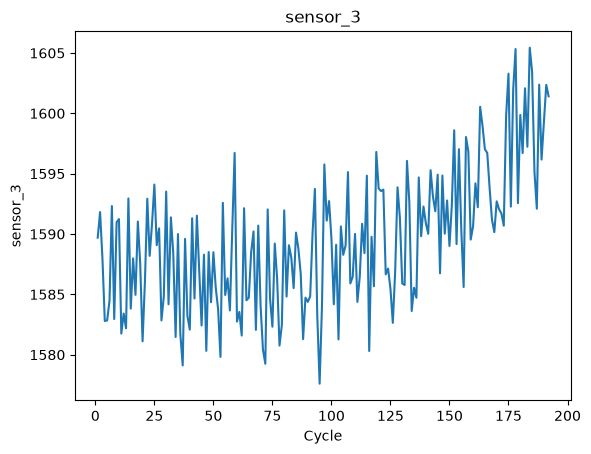

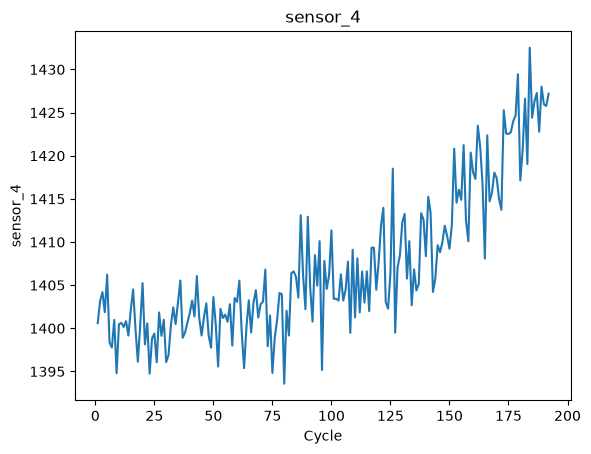

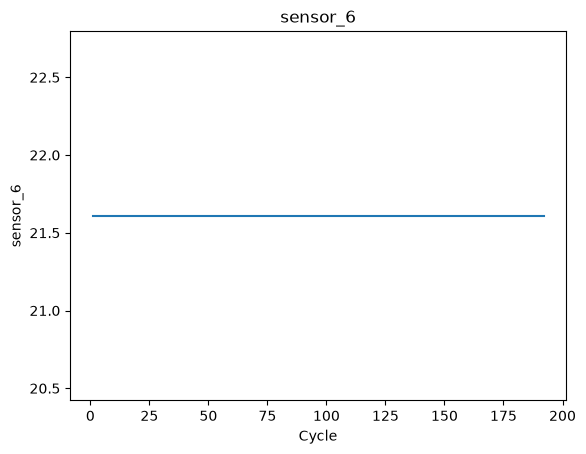

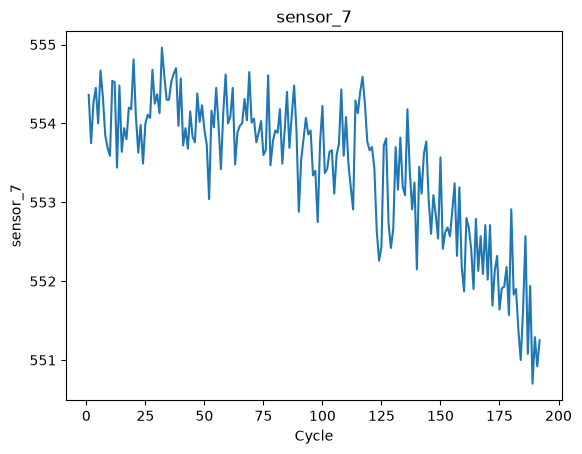

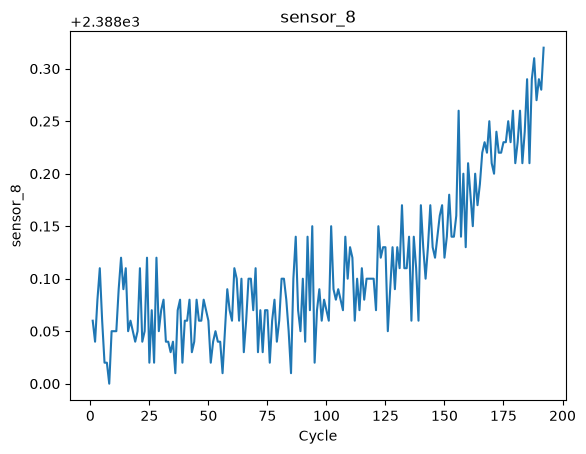

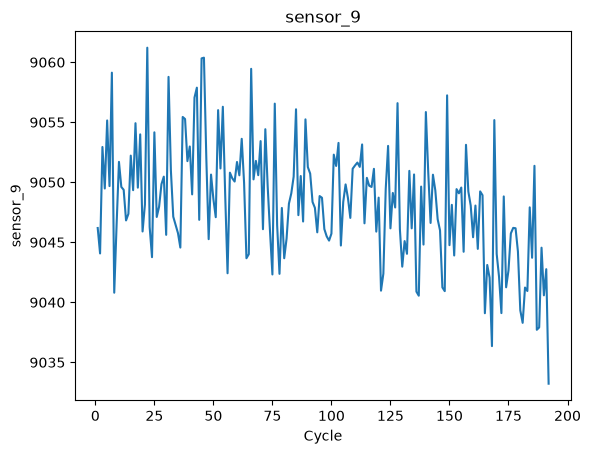

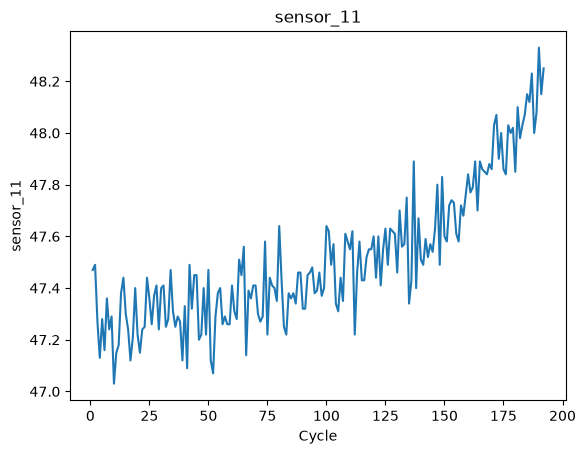

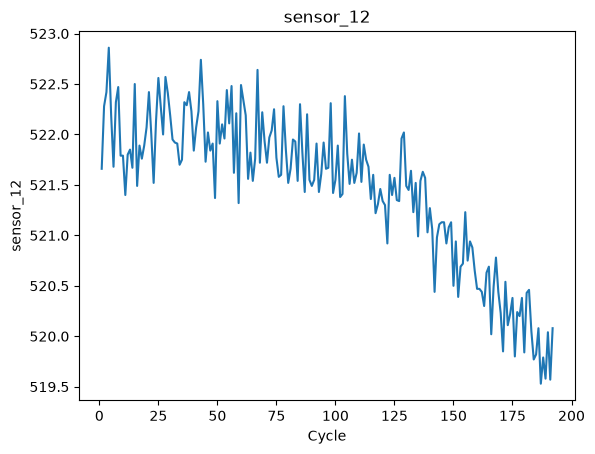

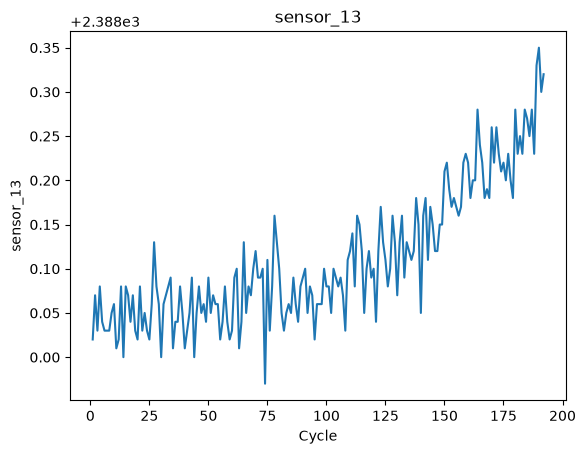

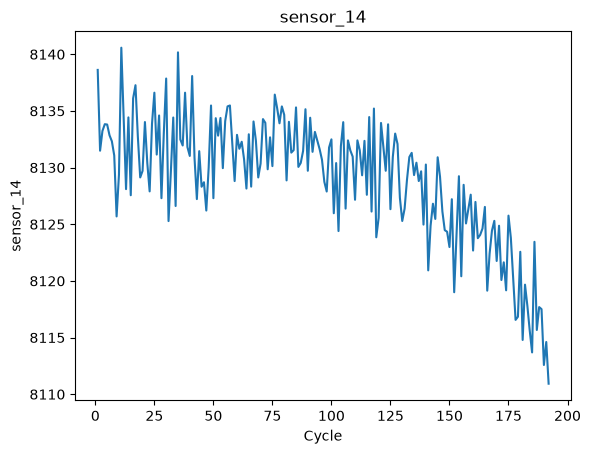

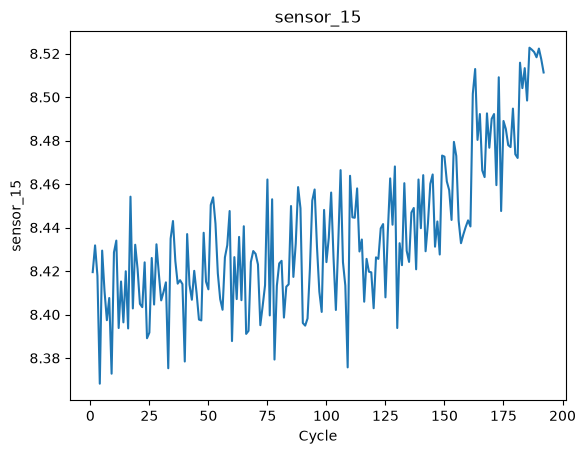

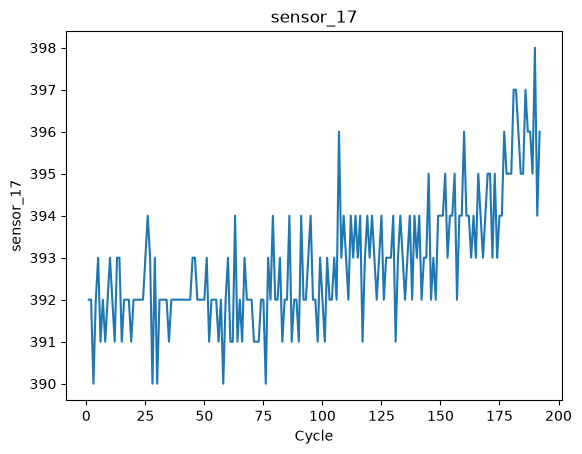

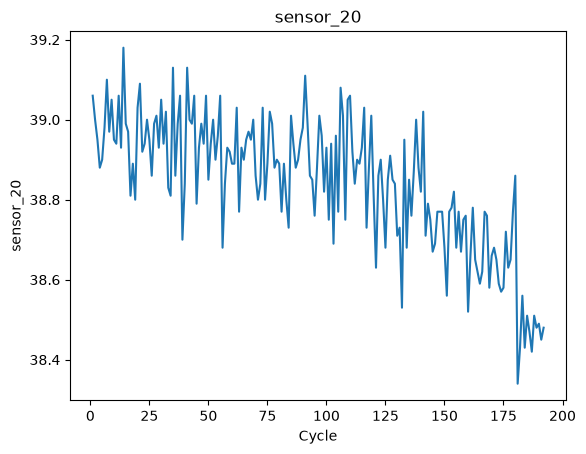

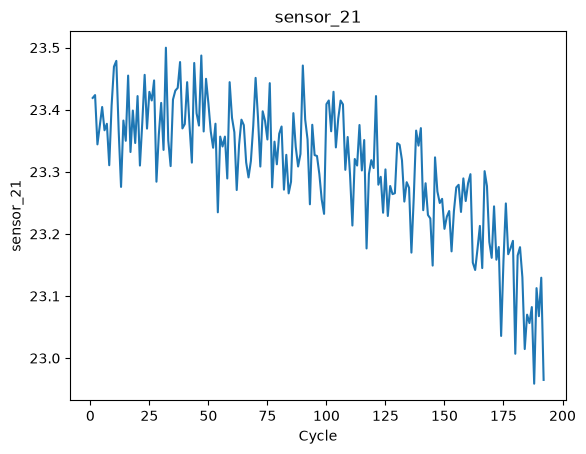

In [25]:
for sensor in sensor_columns:
    plt.figure()
    plt.plot(
        train_df[engine_1_mask]["cycle"],
        train_df[engine_1_mask][sensor]
    )
    plt.title(sensor)
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.show()

In [26]:
sensor_correlations = train_df[sensor_columns + ["RUL"]].corr()["RUL"]

sensor_correlations.abs().sort_values(ascending = False)

RUL          1.000000
sensor_11    0.696228
sensor_4     0.678948
sensor_12    0.671983
sensor_7     0.657223
sensor_15    0.642667
sensor_21    0.635662
sensor_20    0.629428
sensor_2     0.606484
sensor_17    0.606154
sensor_3     0.584520
sensor_8     0.563968
sensor_13    0.562569
sensor_9     0.390102
sensor_14    0.306769
sensor_6     0.128348
Name: RUL, dtype: float64

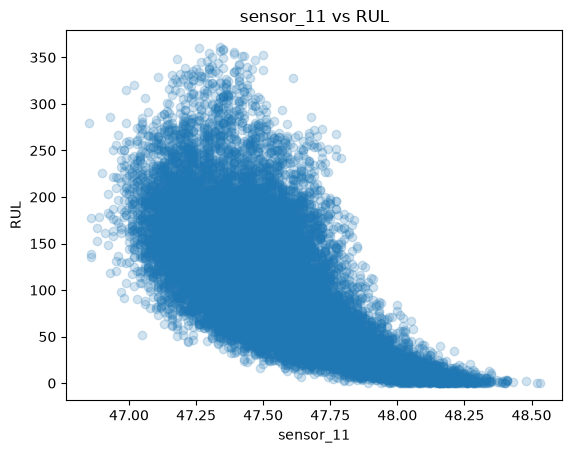

In [27]:
plt.scatter(train_df["sensor_11"], train_df["RUL"], alpha = 0.2)
plt.xlabel("sensor_11")
plt.ylabel("RUL")
plt.title("sensor_11 vs RUL")
plt.show()

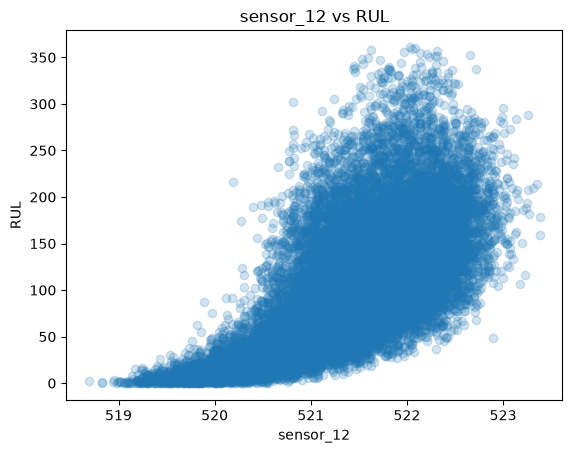

In [28]:
plt.scatter(train_df["sensor_12"], train_df["RUL"], alpha = 0.2)
plt.xlabel("sensor_12")
plt.ylabel("RUL")
plt.title("sensor_12 vs RUL")
plt.show()

In [29]:
sensor_corr_matrix = train_df[sensor_columns].corr()

sensor_corr_matrix

,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
sensor_2,1.000000,0.602610,0.714949,0.132242,-0.702136,0.662325,0.273764,0.740020,-0.724578,0.661792,0.179752,0.675975,0.629886,-0.661841,-0.668050
sensor_3,0.602610,1.000000,0.678413,0.116039,-0.664595,0.602481,0.322964,0.695900,-0.680307,0.600963,0.237137,0.639921,0.600017,-0.625941,-0.633901
sensor_4,0.714949,0.678413,1.000000,0.150480,-0.793130,0.746852,0.297429,0.830136,-0.815591,0.745158,0.190748,0.758459,0.703499,-0.748067,-0.745193
sensor_6,0.132242,0.116039,0.150480,1.000000,-0.155720,0.152161,0.019347,0.160014,-0.155884,0.158276,-0.002112,0.149042,0.130810,-0.141419,-0.137419
sensor_7,-0.702136,-0.664595,-0.793130,-0.155720,1.000000,-0.767132,-0.217835,-0.822805,0.812713,-0.764611,-0.110053,-0.747051,-0.692893,0.736163,0.737447
sensor_8,0.662325,0.602481,0.746852,0.152161,-0.767132,1.000000,-0.032091,0.782213,-0.786540,0.826084,-0.144787,0.700949,0.627785,-0.687030,-0.688840
sensor_9,0.273764,0.322964,0.297429,0.019347,-0.217835,-0.032091,1.000000,0.274591,-0.210238,-0.034763,0.963157,0.293753,0.337110,-0.285280,-0.292795
sensor_11,0.740020,0.695900,0.830136,0.160014,-0.822805,0.782213,0.274591,1.000000,-0.846884,0.780761,0.163408,0.780913,0.722296,-0.771510,-0.772554
sensor_12,-0.724578,-0.680307,-0.815591,-0.155884,0.812713,-0.786540,-0.210238,-0.846884,1.000000,-0.788441,-0.098141,-0.766052,-0.703485,0.751943,0.756263
sensor_13,0.661792,0.600963,0.745158,0.158276,-0.764611,0.826084,-0.034763,0.780761,-0.788441,1.000000,-0.147036,0.697662,0.627410,-0.686172,-0.688948


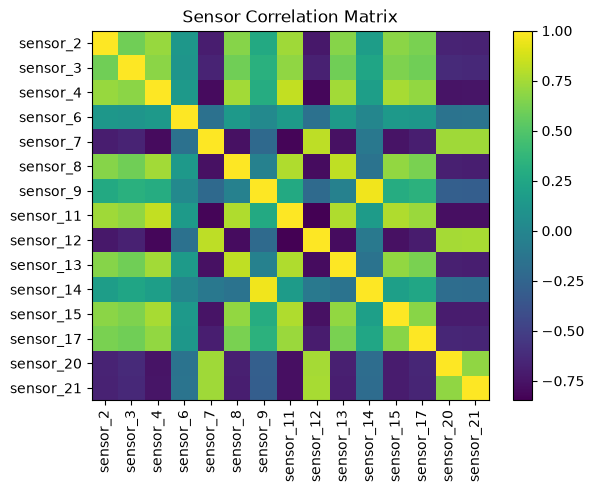

In [30]:
plt.imshow(sensor_corr_matrix, aspect = "auto")
plt.colorbar()
plt.xticks(
    range(len(sensor_columns)), 
    sensor_columns,
    rotation = 90
)
plt.yticks(
    range(len(sensor_columns)),
    sensor_columns 
)
plt.title("Sensor Correlation Matrix")
plt.show()

(array([1300., 1200., 1200., 1200., 1200., 1200., 1200., 1200., 1200.,
        1200., 1195., 1162., 1111.,  991.,  903.,  793.,  589.,  431.,
         317.,  243.,  204.,  174.,  135.,   83.,   52.,   48.,   36.,
          35.,   16.,   13.]),
 array([  0.        ,  12.03333333,  24.06666667,  36.1       ,
         48.13333333,  60.16666667,  72.2       ,  84.23333333,
         96.26666667, 108.3       , 120.33333333, 132.36666667,
        144.4       , 156.43333333, 168.46666667, 180.5       ,
        192.53333333, 204.56666667, 216.6       , 228.63333333,
        240.66666667, 252.7       , 264.73333333, 276.76666667,
        288.8       , 300.83333333, 312.86666667, 324.9       ,
        336.93333333, 348.96666667, 361.        ]),
 <BarContainer object of 30 artists>)

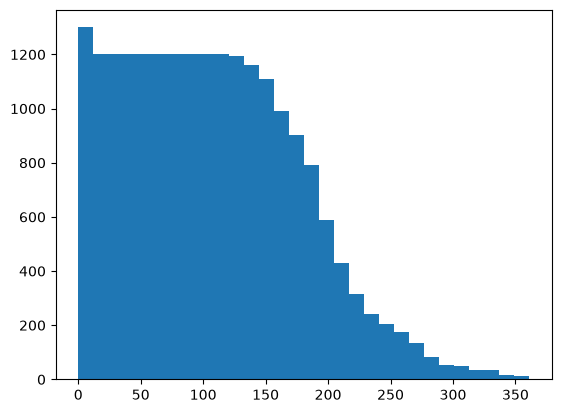

In [31]:
plt.hist(train_df["RUL"], bins = 30)

In [32]:
X = train_df[sensor_columns]

y = train_df["RUL"]

engine_ids = train_df["unit_id"].unique()

engine_ids

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [33]:
# Split the data into traning and validation data
train_ids, val_ids = train_test_split(
    engine_ids,
    test_size = 0.2,
    random_state = 42
)
# Verifying whether the split worked
len(train_ids), len(val_ids)


(80, 20)

In [34]:
# Selecting appropriate rows from train_df by checking if the ids are in train_ids or val_ids
train_mask = train_df["unit_id"].isin(train_ids)
val_mask = train_df["unit_id"].isin(val_ids)

# Create the datasets to be used
X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]

X_train.shape, y_train.shape, X_val.shape, y_val.shape

((16561, 15), (16561,), (4070, 15), (4070,))

In [35]:
# Checking whether training data has leaked into validation data
np.intersect1d(train_ids, val_ids)

array([], dtype=int64)

In [36]:
# Implementation feature scaling by standardization (z- score nomalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Confirmation of whether the data is actually scaled
X_train_scaled.mean(axis = 0)
X_train_scaled.std(axis = 0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [37]:
# Creating and training a Linear Regression model using scikit-learn
model = LinearRegression()

# Train
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-3.8 ,-2.94,-6.78,...,-2.87, 3.57, 4.6 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,108.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[385.97,186.67,126.62,..., 53.47, 49.36, 21.45]"


In [38]:
# Inspect the intercept/bias
model.intercept_

np.float64(108.37781534931382)

In [39]:
# Inspect the coefficients/weights
model.coef_

array([ -3.79654878,  -2.94046274,  -6.77690277,  -0.30809795,
         6.18549003,  -1.08843031,  -7.51337112, -10.11999044,
         7.16750284,  -0.33875172,  -5.41288155,  -4.43148779,
        -2.87181795,   3.56726184,   4.60183207])

In [40]:
# Pair sensor columns with their rightful coefficients
for sensor, coefficient in zip(sensor_columns, model.coef_):
    print(sensor, coefficient)

sensor_2 -3.796548782345701
sensor_3 -2.940462744067009
sensor_4 -6.7769027709219944
sensor_6 -0.30809795133467566
sensor_7 6.185490027890526
sensor_8 -1.0884303057122002
sensor_9 -7.5133711213765775
sensor_11 -10.119990438558405
sensor_12 7.167502838575603
sensor_13 -0.3387517207959771
sensor_14 -5.412881553047701
sensor_15 -4.431487787224856
sensor_17 -2.8718179472954306
sensor_20 3.567261840208093
sensor_21 4.601832065864016


In [41]:
# Prediction
y_pred = model.predict(X_val_scaled)

y_pred.shape

(4070,)

In [42]:
for predicted, actual in zip(y_pred[:10], y_val.iloc[:10]):
    print("Predicted:", predicted, "Actual:", actual)

Predicted: 157.44426063222772 Actual: 191
Predicted: 153.26977088691245 Actual: 190
Predicted: 163.25831744799052 Actual: 189
Predicted: 180.8070415725767 Actual: 188
Predicted: 153.62262019912902 Actual: 187
Predicted: 173.7813972737349 Actual: 186
Predicted: 163.41315671399107 Actual: 185
Predicted: 169.43049392596862 Actual: 184
Predicted: 170.6090067845688 Actual: 183
Predicted: 167.98012921169425 Actual: 182


In [43]:
# Calculate mean absolute error
mae = mean_absolute_error(y_val, y_pred)

print("MAE:", mae)

MAE: 30.101522152946615


In [44]:
# Calculate Root Mean Squared Error
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 38.1238851477566


In [46]:
# Calculate coefficient of determination
r2 = r2_score(y_val, y_pred)

print("R2:", r2)

R2: 0.6627906322148942


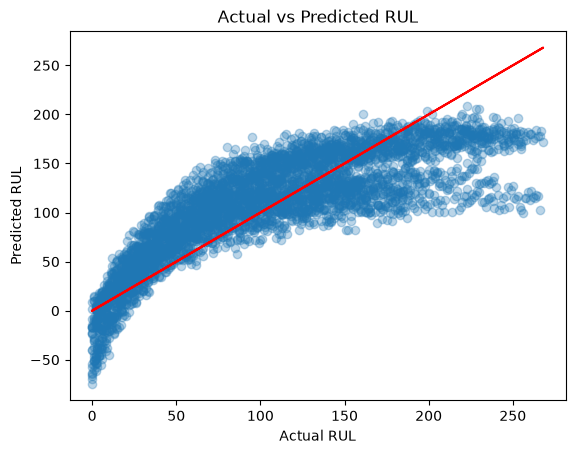

In [51]:
# Visualising the Linear Regression Errors
plt.scatter(y_val, y_pred, alpha = 0.3)
plt.plot(y_val, y_val, color = "red")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

In [ ]:
# Residual/error
residual = y_val - y_pred

print(residual)

0        33.555739
1        36.730229
2        25.741683
3         7.192958
4        33.377380
           ...    
18510   -12.151517
18511     2.033897
18512    11.847026
18513    15.443897
18514    17.665421
Name: RUL, Length: 4070, dtype: float64


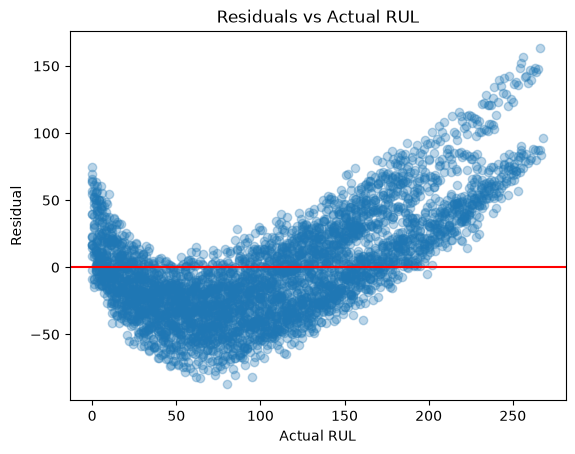

In [ ]:
plt.scatter(y_val, residual, alpha = 0.3)
plt.axhline(y = 0, color = "Red")

plt.xlabel("Actual RUL")
plt.ylabel("Residual")
plt.title("Residuals vs Actual RUL")
plt.show()

In [58]:
mean_rul = y_train.mean()
print("Mean Training RUL:", mean_rul)

Mean Training RUL: 108.37781534931466


In [60]:
# Naive baseline to compare with RMSE
baseline_pred = np.full(len(y_val), mean_rul)
baseline_pred.shape

(4070,)

In [62]:
# Calculate RMSE
baseline_mse = mean_squared_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 65.71544508456086


### Linear Regression Baseline Results

- Naive baseline RMSE: 65.72
- Linear Regression MAE: 30.10
- Linear Regression RMSE: 38.12
- Linear Regression R²: 0.663

The Linear Regression model significantly outperforms the naive mean-RUL
baseline. However, the residual plot shows a clear nonlinear pattern,
indicating that Linear Regression does not fully capture the relationship
between the sensor measurements and RUL.